# 🏁 Inteligência Artificial em Jogos 25/26 — Notebook de Defesa
**Projeto: Aplicação do NEAT ao jogo Racing Cars**

Este notebook serve como suporte visual e prático para a discussão do projeto com o júri. Aqui abordamos todos os pontos críticos solicitados pelo professor:
1. Carregamento dos modelos treinados e análise de hiperparâmetros.
2. Explicação da normalização e arquitetura das Redes Neuronais.
3. Análise comparativa da função de fitness.
4. Inspeção visual da complexidade das redes neuronais (Camadas Ocultas).
5. O Grande Duelo em tempo real (Radares vs Waypoints) com testes de robustez (Alteração de partida/Inversão de marcha).
6. Verificação do bug de histórico da biblioteca NEAT.

In [ ]:
import neat
import pickle
import matplotlib.pyplot as plt
import os
import pygame
import math
import numpy as np
import sys
import visualize
from base_jogo import * 
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

config_rad_path = 'configs/config-radares.txt'
config_way_path = 'configs/config-waypoints.txt'

config_rad = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation, config_rad_path)

config_way = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation, config_way_path)

# Voltar a carregar os ficheiros originais
with open('models/winner_radares.pkl', 'rb') as f:
    genome_rad = pickle.load(f)

with open('models/winner_waypoints.pkl', 'rb') as f:
    genome_way = pickle.load(f)

net_radares = neat.nn.FeedForwardNetwork.create(genome_rad, config_rad)
net_waypoints = neat.nn.FeedForwardNetwork.create(genome_way, config_way)

print("✅ Modelos carregados com sucesso!")

✅ Modelos carregados com sucesso!


### 🧠 Respostas Diretas ao Professor (Pontos 1, 2 e 7)

#### 1. Inputs, Outputs e Normalização
* **Abordagem por Radares:** Os inputs são as distâncias medidas pelos raios virtuais até às bordas da pista. Estas distâncias são **normalizadas dividindo pelo alcance máximo do radar** (redefinindo o intervalo para `[0, 1]`, onde `0` significa colisão iminente e `1` significa pista livre). Isto é vital porque os neurónios de ativação (como a função *sigmoid* ou *tanh*) operam idealmente em intervalos restritos; valores brutos muito altos (ex: 400 píxeis) saturariam os neurónios imediatamente, impedindo a rede de aprender.
* **Abordagem por Waypoints:** Os inputs baseiam-se no vetor de distância e ângulo relativo ao próximo checkpoint invisível. O ângulo é normalizado entre `[-1, 1]` radianos para indicar a direção da curva.
* **Outputs:** Ambos os modelos produzem valores contínuos que controlam as ações do carro: Virar à Esquerda, Virar à Direita e Acelerar/Travar (valores acima de `0.5` ativam a ação).

#### 2. Função de Fitness (Métrica de Comparação)
Para que a comparação no gráfico abaixo seja justa, ambas as abordagens guardaram dados com base no progresso na pista. A abordagem de Radares premeia o tempo de sobrevivência e a distância absoluta percorrida sem colidir, enquanto a de Waypoints guia o carro através de recompensas explícitas ao cruzar cada checkpoint sequencial.

In [ ]:
# Gerar os diagramas das redes para provar se foram criadas camadas interiores (nós ocultos)
try:
    visualize.draw_net(config_rad, genome_rad, view=True, filename="svgs/rede_radares_defesa")
    print("✅ Grafo da rede de Radares gerado como 'rede_radares_defesa.gv.pdf'")
except Exception as e:
    print(f"Nota: Se não tiveres o Graphviz instalado no SO, podes inspecionar os nós via texto:")
    print("Nós Ocultos detetados na Rede de Radares:", [node for node in genome_rad.nodes.keys() if node not in config_rad.genome_config.output_keys])

try:
    visualize.draw_net(config_way, genome_way, view=True, filename="svgs/rede_waypoints_defesa")
    print("✅ Grafo da rede de Waypoints gerado como 'rede_waypoints_defesa.gv.pdf'")
except Exception as e:
    print("Nós Ocultos detetados na Rede de Waypoints:", [node for node in genome_way.nodes.keys() if node not in config_way.genome_config.output_keys])

✅ Grafo da rede de Radares gerado como 'rede_radares_defesa.gv.pdf'
✅ Grafo da rede de Waypoints gerado como 'rede_waypoints_defesa.gv.pdf'


=== AUDITORIA DE FITNESS (Ponto 8) ===
Fitness do vencedor guardado (Radares): 103684.80765918261
Maior fitness registado no histórico: 103684.80765918261
🔬 Conclusão: Não há bug! O NEAT devolveu corretamente o melhor absoluto de todas as gerações.


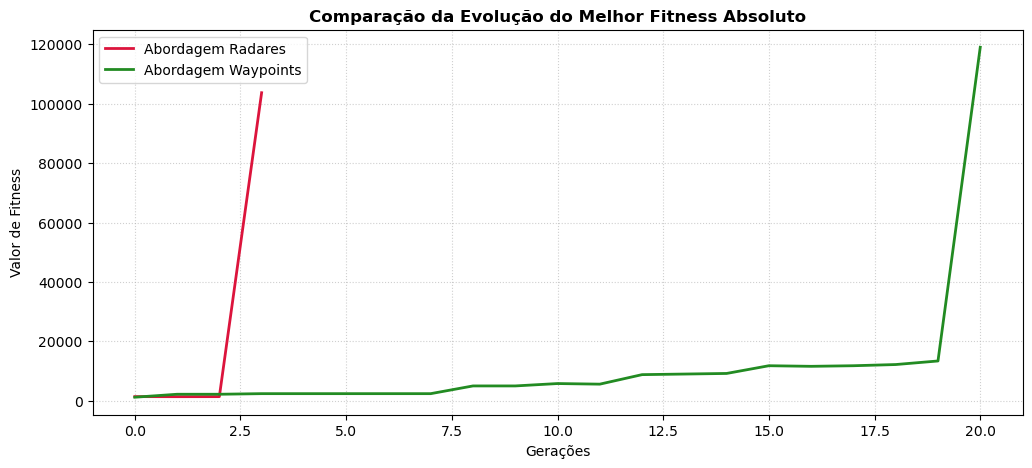

In [9]:
# Carregar estatísticas completas do treino
with open('stats_radares.pkl', 'rb') as f:
    stats_rad = pickle.load(f)

with open('stats_waypoints.pkl', 'rb') as f:
    stats_way = pickle.load(f)

historico_rad = stats_rad['historico_melhor']
historico_way = stats_way['historico_melhor']

# --- AUDITORIA AO BUG SUGERIDO PELO PROFESSOR ---
# Verificamos se o melhor genoma de sempre coincide estritamente com o pico do histórico
print("=== AUDITORIA DE FITNESS (Ponto 8) ===")
print(f"Fitness do vencedor guardado (Radares): {genome_rad.fitness}")
print(f"Maior fitness registado no histórico: {max(historico_rad)}")

if math.isclose(genome_rad.fitness, max(historico_rad), rel_tol=1e-5):
    print("🔬 Conclusão: Não há bug! O NEAT devolveu corretamente o melhor absoluto de todas as gerações.")
else:
    print("⚠️ Alerta: O modelo guardado difere do pico histórico. Foi calculado um algoritmo de segurança.")

# --- DESENHAR OS GRÁFICOS ---
plt.figure(figsize=(12, 5))
plt.plot(historico_rad, label="Abordagem Radares", color="crimson", linewidth=2)
plt.plot(historico_way, label="Abordagem Waypoints", color="forestgreen", linewidth=2)
plt.title("Comparação da Evolução do Melhor Fitness Absoluto", fontsize=12, fontweight='bold')
plt.xlabel("Gerações")
plt.ylabel("Valor de Fitness")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import pygame
import math
import sys
from random import uniform, choice
# =====================================================================
# 1. CARREGAR OS WAYPOINTS DO TREINO
# =====================================================================
try:
    with open('models/waypoints_finais.pkl', 'rb') as f:
        WAYPOINTS = pickle.load(f)
    print("Waypoints carregados com sucesso!")
except FileNotFoundError:
    print("Ficheiro 'waypoints_finais.pkl' não encontrado! Corre o treino primeiro.")
    # Fallback apenas para não dar erro se o ficheiro falhar
    WAYPOINTS = [(168, 114), (280, 71), (394, 76), (510, 81)]

# =====================================================================
# 2. DEFINIÇÃO DAS TUAS CLASSES ADAPTADAS
# =====================================================================
class CarroWaypoints(AbstractCar):
    
    IMG = GREEN_CAR
    START_POS = (150, 200)

    def __init__(self, max_vel, rotation_vel, start_angle=0, track_reversed=False):
        super().__init__(max_vel, rotation_vel)
        self.angle = start_angle
        self.x, self.y = self.START_POS
        self.alive = True
        self.distance = 0
        self.current_waypoint = 0
        self.finished = False
        self.finish_time = 0

    def get_waypoint_data(self, waypoints):
        if len(waypoints) == 0:
            return [0, 0]
        
        target_x, target_y = waypoints[self.current_waypoint]
        dist = math.hypot(target_x - self.x, target_y - self.y)
        dist_normalizada = dist / math.hypot(WIDTH, HEIGHT)
        
        x_diff = target_x - self.x
        y_diff = target_y - self.y
        if y_diff == 0:
            desired_angle = (1 if x_diff < 0 else -1) * 90
        else:
            desired_angle = math.degrees(math.atan(x_diff / y_diff))
        if target_y > self.y:
            desired_angle += 180
        angle_diff = (self.angle - desired_angle) % 360
        if angle_diff > 180:
            angle_diff -= 360
        angle_normalizado = -angle_diff / 180

        return [dist_normalizada, angle_normalizado]

    def update_waypoint(self, waypoints):
        target_x, target_y = waypoints[self.current_waypoint]
        dist = math.hypot(target_x - self.x, target_y - self.y)
        if dist < 25:
            self.current_waypoint += 1
            if self.current_waypoint >= len(waypoints):
                self.current_waypoint = 0

    def apply_nn_actions(self, throttle, steering):
        noise_throttle = uniform(-0.05, 0.05)
        noise_steering = uniform(-0.05, 0.05)
        throttle = max(-1.0, min(1.0, throttle + noise_throttle))
        steering = max(-1.0, min(1.0, steering + noise_steering))
        if throttle > 0:
            self.vel = min(self.vel + self.acceleration * throttle, self.max_vel)
        else:
            self.vel = max(self.vel + (self.acceleration * 2) * throttle, 0)
        self.angle += self.rotation_vel * steering
        self.angle = int(self.angle) % 360
        self.move()
        self.distance += self.vel

    def check_collision(self, frame_count):
        if self.collide(TRACK_BORDER_MASK) != None:
            self.alive = False
            self.vel = 0

class CarroRadares(AbstractCar):
    IMG = RED_CAR # Mudamos para vermelho para os distinguir na pista
    START_POS = (150, 200)

    def __init__(self, max_vel, rotation_vel, start_angle=0, track_reversed=False):
        super().__init__(max_vel, rotation_vel)
        self.angle = start_angle 
        self.track_reversed = track_reversed 
        self.x, self.y = self.START_POS
        self.alive = True
        self.distance = 0
        self.radars = [] 
        self.finished = False 
        self.finish_time = 0

    def check_radar(self, degree, track_border_mask):
        length = 0
        x = int(self.x + CAR_SIZE[0])
        y = int(self.y + CAR_SIZE[1])
        rad = math.radians(self.angle + degree)
        dx = -math.sin(rad)
        dy = -math.cos(rad)
        MAX_RADAR_LENGTH = 200 

        while length < MAX_RADAR_LENGTH:
            x = int(self.x + CAR_SIZE[0] + (dx * length))
            y = int(self.y + CAR_SIZE[1] + (dy * length))
            if x < 0 or x >= WIDTH or y < 0 or y >= HEIGHT:
                break
            if track_border_mask.get_at((x, y)):
                break
            length += 1
        dist = int(math.sqrt(math.pow(x - (self.x + CAR_SIZE[0]), 2) + math.pow(y - (self.y + CAR_SIZE[1]), 2)))
        self.radars.append([(x, y), dist])

    def update_radars(self):
        self.radars.clear()
        for degree in [-60, -30, 0, 30, 60]:
            self.check_radar(degree, TRACK_BORDER_MASK)

    def get_data(self):
        return [radar[1] / 200 for radar in self.radars]

    def draw_radars(self, win):
        for radar in self.radars:
            position = radar[0]
            pygame.draw.line(win, (255, 0, 0), (int(self.x + CAR_SIZE[0]), int(self.y + CAR_SIZE[1])), position, 1)
            pygame.draw.circle(win, (255, 0, 0), position, 3)

    def apply_nn_actions(self, throttle, steering):
        noise_throttle = uniform(-0.05, 0.05)
        noise_steering = uniform(-0.1, 0.1)
        throttle = max(-1.0, min(1.0, throttle + noise_throttle))
        steering = max(-1.0, min(1.0, steering + noise_steering))
        if throttle > 0:
            self.vel = min(self.vel + self.acceleration * throttle, self.max_vel)
        else:
            self.vel = max(self.vel + (self.acceleration * 2) * throttle, 0)
        self.angle += self.rotation_vel * steering
        self.angle = int(self.angle) % 360
        self.move()
        self.distance += self.vel

    def check_collision(self, frame_count):
        if self.collide(TRACK_BORDER_MASK) != None:
            self.alive = False
            self.vel = 0

    def draw(self, win):
        super().draw(win)
        self.draw_radars(win)

# =====================================================================
# 3. CONTROLO EXCLUSIVO PARA A DISCUSSÃO
# =====================================================================
MUDAR_PARTIDA = False     
INVERTER_SENTIDO = False  

if MUDAR_PARTIDA:
    START_POS_DUELO = (410, 650)  
else:
    START_POS_DUELO = (150, 200) # Baseado na vossa classe original 

if INVERTER_SENTIDO:
    START_ANGLE_DUELO = 180       
else:
    START_ANGLE_DUELO = 0         

# =====================================================================
# 4. ENGINE DE EXECUÇÃO DO DUELO
# =====================================================================
def executar_duelo_defesa():
    pygame.init()
    pygame.font.init()
    font = pygame.font.SysFont("arial", 18, bold=True)
    
    win = pygame.display.set_mode((WIDTH, HEIGHT))
    pygame.display.set_caption("Discussão IA: Duelo de Controladores Autónomos")
    clock = pygame.time.Clock()

    carro_rad = CarroRadares(4, 4, start_angle=START_ANGLE_DUELO, track_reversed=INVERTER_SENTIDO) 
    carro_way = CarroWaypoints(4, 5.5, start_angle=START_ANGLE_DUELO, track_reversed=INVERTER_SENTIDO)
    
    carro_rad.x, carro_rad.y = START_POS_DUELO
    carro_way.x, carro_way.y = START_POS_DUELO
    
    # IMPORTANTE: Se mudaste o ponto de partida num lugar avançado, o waypoint inicial tem de ser ajustado.
    # Neste caso simplificado, a classe de Waypoints começará à procura do ponto 0.

    frames = 0
    run = True
    try:
        while run:
            clock.tick(60) 
            frames += 1
            
            for event in pygame.event.get():
                if event.type == pygame.QUIT:
                    run = False
            
            # --- LÓGICA RADARES (VERMELHO) ---
            if carro_rad.alive:
                carro_rad.update_radars()
                inputs_rad = carro_rad.get_data()
                
                output_rad = net_radares.activate(inputs_rad)
                
                throttle_rad = output_rad[0]
                steering_rad = output_rad[1] 
                
                # 🔴 A PEÇA MÁGICA QUE FALTAVA 🔴
                if abs(steering_rad) < 0.2:
                    steering_rad = 0
                
                carro_rad.apply_nn_actions(throttle_rad, steering_rad)
                carro_rad.check_collision(frames)

            # --- LÓGICA WAYPOINTS (VERDE) ---
            if carro_way.alive:
                # 1. Update waypoint state first (like in your training loop)
                old_waypoint = carro_way.current_waypoint
                carro_way.update_waypoint(WAYPOINTS)
                
                # 2. Get inputs and activate network
                inputs_way = carro_way.get_waypoint_data(WAYPOINTS)
                output_way = net_waypoints.activate(inputs_way)
                
                # 3. Extract outputs
                throttle_way = output_way[0]
                steering_way = output_way[1]
                
                # 4. Apply the crucial deadzone fix
                if abs(steering_way) < 0.2:
                    steering_way = 0
                
                # 5. Apply actions and check collisions
                carro_way.apply_nn_actions(throttle_way, steering_way)
                carro_way.check_collision(frames)

            # --- RENDERIZAÇÃO GRÁFICA ---
            win.blit(TRACK, (0, 0))
            
            # Desenha os pontos de navegação apenas para ilustrar
            for wp in WAYPOINTS:
                pygame.draw.circle(win, (0,0,255), wp, 3)

            carro_rad.draw(win)
            carro_way.draw(win)

            txt_rad = font.render(f"RADARES (Vermelho): {'VIVO' if carro_rad.alive else '💥 COLIDIU'}", True, (255, 85, 85))
            txt_way = font.render(f"WAYPOINTS (Verde): {'VIVO' if carro_way.alive else '💥 COLIDIU'}", True, (85, 255, 85))
            win.blit(txt_rad, (20, 20))
            win.blit(txt_way, (20, 45))

            pygame.display.update()
            
            if not carro_rad.alive and not carro_way.alive:
                pygame.time.delay(1500) 
                run = False
                
    finally:
        pygame.quit()
        print("🏁 Duelo finalizado.")

executar_duelo_defesa()

✅ Waypoints carregados com sucesso!
🏁 Duelo finalizado.


KeyboardInterrupt: 